## Taller Práctico: Implementación de Modelos Preentrenados

### Objetivos de Aprendizaje
1. Comprender la diferencia entre entrenar desde cero y hacer *Transfer Learning* o usar modelos preentrenados.
2. Cargar y ejecutar modelos de Visión por Computadora usando PyTorch nativo (`torchvision`).
3. Implementar arquitecturas basadas en Transformers de forma robusta con Hugging Face.
4. Utilizar ecosistemas de NLP orientados a producción (spaCy) para extracción de entidades.

In [1]:
# 0. INSTALACIÓN DE DEPENDENCIAS CORE (5 minutos)
# Ejecutar una sola vez al inicio de la clase
!pip install -q transformers torch torchvision
!pip install -q spacy
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Usuario\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Usuario\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------- -------------------------------- 2.4/12.8 MB 16.8 MB/s eta 0:00:01
     ------------------ --------------------- 6.0/12.8 MB 17.6 MB/s eta 0:00:01
     ------------------------------ --------- 9.7/12.8 MB 17.8 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 17.4 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Usuario\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Parte 1: PyTorch y Torchvision (Visión por Computadora)
Vamos a usar una red convolucional clásica (ResNet50) preentrenada con ImageNet (1 millón de imágenes, 1000 categorías). Observen cómo el preprocesamiento de la imagen es manual.

ID de categoría predicha: 734 con probabilidad 0.1565


100%|██████████| 10.2k/10.2k [00:00<00:00, 21.0MB/s]

Etiqueta predicha: police van


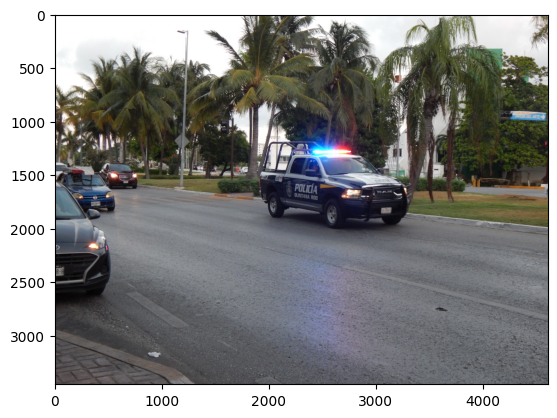

In [10]:
import torch
from torchvision import models, transforms
from PIL import Image
import urllib.request
import matplotlib.pyplot as plt

# 1. Cargar el modelo preentrenado y ponerlo en modo evaluación
#resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
#resnet.eval()

mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
mobilenet.eval()

# 2. Descargar una imagen de prueba (un perro Golden Retriever)
url, filename = ("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
urllib.request.urlretrieve(url, filename)
img = Image.open("D:\\Fotos\\Cancun\\DSCN6985.JPG")

plt.imshow(img)


# 3. Definir el pipeline de preprocesamiento matemático (Tensor, Normalización)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 4. Procesar la imagen e inferir
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0) # Crear un mini-batch

with torch.no_grad():
    output = mobilenet(input_batch)

# 5. Obtener la predicción
probabilities = torch.nn.functional.softmax(output[0], dim=0)
top_prob, top_catid = torch.topk(probabilities, 1)
print(f"ID de categoría predicha: {top_catid.item()} con probabilidad {top_prob.item():.4f}")

## traer la lista de etiquetas de ImageNet de torch

torch.hub.download_url_to_file('https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt', 'imagenet_classes.txt')

with open("imagenet_classes.txt") as f:
    labels = [line.strip() for line in f.readlines()]

# 6. Mostrar la etiqueta de la predicción
print(f"Etiqueta predicha: {labels[top_catid.item()]}")


## Parte 2: Transformers y Hugging Face (Procesamiento de Lenguaje Natural)
A diferencia de `torchvision`, Hugging Face estandariza el preprocesamiento mediante el `Tokenizer`. Utilizaremos la clase de Control Total (`AutoClasses`) para garantizar estabilidad en la traducción de textos.

In [12]:
# CELDA - TRANSLATION A PRUEBA DE FALLOS (AUTOCLASSES)
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Definimos el modelo
model_id_trans = "Helsinki-NLP/opus-mt-en-es"

# 2. Forzamos la descarga explícita del Tokenizador y el Modelo correcto
print("Cargando tokenizador y modelo...")
tokenizer_trans = AutoTokenizer.from_pretrained(model_id_trans)
model_trans = AutoModelForSeq2SeqLM.from_pretrained(model_id_trans)

texto_ingles = """
My Wonderful Family
I live in a house near the mountains. I have two brothers and one sister, and I was born last. My father teaches mathematics, and my mother is a nurse at a big hospital. My brothers are very smart and work hard in school. My sister is a nervous girl, but she is very kind. My grandmother also lives with us. She came from Italy when I was two years old. She has grown old, but she is still very strong. She cooks the best food!
My family is very important to me. We do lots of things together. My brothers and I like to go on long walks in the mountains. My sister likes to cook with my grandmother. On the weekends we all play board games together. We laugh and always have a good time. I love my family very much.
"""
# 3. Tokenizamos el texto (lo convertimos a tensores de PyTorch)
inputs_trans = tokenizer_trans(texto_ingles, return_tensors="pt")

# 4. Generamos la traducción
print("Traduciendo...")
translated_ids = model_trans.generate(**inputs_trans)

# 5. Decodificamos los números de vuelta a texto legible en español
traduccion_final = tokenizer_trans.decode(translated_ids[0], skip_special_tokens=True)

print("-" * 30)
print("Texto Original:", texto_ingles)
print("Traducción:", traduccion_final)

Cargando tokenizador y modelo...


C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Traduciendo...
------------------------------
Texto Original: 
My Wonderful Family
I live in a house near the mountains. I have two brothers and one sister, and I was born last. My father teaches mathematics, and my mother is a nurse at a big hospital. My brothers are very smart and work hard in school. My sister is a nervous girl, but she is very kind. My grandmother also lives with us. She came from Italy when I was two years old. She has grown old, but she is still very strong. She cooks the best food!
My family is very important to me. We do lots of things together. My brothers and I like to go on long walks in the mountains. My sister likes to cook with my grandmother. On the weekends we all play board games together. We laugh and always have a good time. I love my family very much.

Traducción: Mi familia maravillosa Vivo en una casa cerca de las montañas. Tengo dos hermanos y una hermana, y nací el último. Mi padre enseña matemáticas, y mi madre es enfermera en un hospital grand

In [ ]:
# CELDA - TRANSLATION A PRUEBA DE FALLOS (AUTOCLASSES)
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Definimos el modelo
model_id_trans = "facebook/bart-large-cnn"

# 2. Forzamos la descarga explícita del Tokenizador y el Modelo correcto
print("Cargando tokenizador y modelo...")
tokenizer_trans = AutoTokenizer.from_pretrained(model_id_trans)
model_trans = AutoModelForSeq2SeqLM.from_pretrained(model_id_trans)

texto_largo = """
The Three Little PigsOnce upon a time, there were three little pigs who left their mother to seek their fortune.The first little pig built a house of straw because it was the easiest and quickest.The second little pig built a house of sticks. It took a little longer, but it was a bit stronger.The third little pig was very hardworking and built a house of bricks.One day, a big bad wolf came to the neighborhood. He went to the first pig's house, knocked on the door, and said: “Little pig, little pig, let me come in!”The pig replied: “No, no, not by the hair on my chinny-chin-chin!”The wolf got angry, huffed and puffed, and blew the straw house down! The little pig ran to the stick house. The wolf then went to the stick house and blew that one down too.The two terrified pigs ran to their brother's brick house. The wolf huffed and puffed as hard as he could, but he could not blow the brick house down because it was too strong.Realizing he couldn't break in, the wolf decided to climb down the chimney. But the clever third pig had a pot of boiling water waiting in the fireplace. The wolf fell right in, screamed, and ran away, never to bother the three little pigs again.

"""
# 3. Tokenizamos el texto (lo convertimos a tensores de PyTorch)
inputs_trans = tokenizer_trans(texto_largo, return_tensors="pt", max_length=1024, truncation=True)

# 4. Generamos la traducción
print("Traduciendo...")
translated_ids = model_trans.generate(**inputs_trans)

# 5. Decodificamos los números de vuelta a texto legible en español
traduccion_final = tokenizer_trans.decode(translated_ids[0], skip_special_tokens=True)

print("-" * 30)
print("Texto Original:", texto_largo)
print("Traducción:", traduccion_final)

Cargando tokenizador y modelo...


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Traduciendo...
------------------------------
Texto Original: 
The Three Little PigsOnce upon a time, there were three little pigs who left their mother to seek their fortune.The first little pig built a house of straw because it was the easiest and quickest.The second little pig built a house of sticks. It took a little longer, but it was a bit stronger.The third little pig was very hardworking and built a house of bricks.One day, a big bad wolf came to the neighborhood. He went to the first pig's house, knocked on the door, and said: “Little pig, little pig, let me come in!”The pig replied: “No, no, not by the hair on my chinny-chin-chin!”The wolf got angry, huffed and puffed, and blew the straw house down! The little pig ran to the stick house. The wolf then went to the stick house and blew that one down too.The two terrified pigs ran to their brother's brick house. The wolf huffed and puffed as hard as he could, but he could not blow the brick house down because it was too strong.R

: 